In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, average_precision_score

In [9]:
train_df = pd.read_csv('train_c.csv')
test_df = pd.read_csv('test_c.csv')
X = train_df.drop(["임신 성공 여부"], axis=1)
y = train_df["임신 성공 여부"]

In [4]:
categorical_cols = X.select_dtypes(include=['object']).columns
encoder_dict = {}
for col in categorical_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[col] = encoder.fit_transform(train_df[[col]])
    test_df[col] = encoder.transform(test_df[[col]])
    encoder_dict[col] = encoder

In [ ]:
# # One-Hot Encoder 설정 (handle_unknown='ignore'로 새로운 값 처리)
# encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# # 원-핫 인코딩 적용
# X_encoded = encoder.fit_transform(X[categorical_cols])
# test_encoded = encoder.transform(test_df[categorical_cols])

# # 컬럼명 생성
# encoded_cols = encoder.get_feature_names_out(categorical_cols)

# # DataFrame 변환
# X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_cols, index=X.index)
# test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_cols, index=test_df.index)

# # 기존 데이터에서 범주형 컬럼 삭제 후 원핫 인코딩된 컬럼 결합
# X = X.drop(columns=categorical_cols).reset_index(drop=True).join(X_encoded_df)
# test_df = test_df.drop(columns=categorical_cols).reset_index(drop=True).join(test_encoded_df)

In [12]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
xgb_model = XGBClassifier(
    colsample_bytree=0.8,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=10,
    n_estimators=300,
    subsample=0.8,
    use_label_encoder=False, eval_metric="auc", n_jobs=-1,random_state=42
    )
xgb_model.fit(X_train, y_train)

# Train 데이터에 대한 예측 수행
y_train_proba = xgb_model.predict_proba(X_train)[:, 1]
y_train_pred = (y_train_proba > 0.5).astype(int)

# Validation 데이터에 대한 예측 수행
y_val_proba = xgb_model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba > 0.5).astype(int)

# 평가 지표 출력 함수 정의
def print_metrics(y_true, y_pred, y_proba, dataset_name="Dataset"):
    print(f"\n=== {dataset_name} 평가 지표 ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))
    print("AUC PR:", average_precision_score(y_true, y_proba))
    print("ROC AUC:", roc_auc_score(y_true, y_proba))

# Train 데이터 평가
print_metrics(y_train, y_train_pred, y_train_proba, "Train")

# Validation 데이터 평가
print_metrics(y_val, y_val_pred, y_val_proba, "Validation")

d:\env\envs\aimers\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:19:44] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== Train 평가 지표 ===
Accuracy: 0.7455708130073321
              precision    recall  f1-score   support

           0       0.75      0.99      0.85    150966
           1       0.61      0.05      0.10     52796

    accuracy                           0.75    203762
   macro avg       0.68      0.52      0.47    203762
weighted avg       0.71      0.75      0.66    203762

AUC PR: 0.45777492878465054
ROC AUC: 0.7406399288945381

=== Validation 평가 지표 ===
Accuracy: 0.7429182780078915
              precision    recall  f1-score   support

           0       0.75      0.99      0.85     37685
           1       0.57      0.05      0.09     13256

    accuracy                           0.74     50941
   macro avg       0.66      0.52      0.47     50941
weighted avg       0.70      0.74      0.65     50941

AUC PR: 0.4484864483851913
ROC AUC: 0.7357386971407762


#### 전체 데이터로 재학습

In [ ]:
model_full = XGBClassifier(
    colsample_bytree=0.8,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=10,
    n_estimators=300,
    subsample=0.8,
    use_label_encoder=False, eval_metric="auc", n_jobs=-1,random_state=42
    )
model_full.fit(X, y)

c:\Users\jiwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:53:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

## Submission

In [10]:
# 테스트 세트에 대해 예측 확률 산출 (양성 클래스에 대한 확률)
y_test_pred_proba = model_full.predict_proba(test_df)[:, 1]
sample_submission = pd.read_csv('Data\sample_submission.csv')
sample_submission['probability'] = y_test_pred_proba
sample_submission.to_csv('./XG.csv', index=False)

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\jiwoo\AppData\Local\Temp\ipykernel_504\2881755021.py:3: SyntaxWarning: invalid escape sequence '\s'
  sample_submission = pd.read_csv('Data\sample_submission.csv')
C:\Users\jiwoo\AppData\Local\Temp\ipykernel_504\2881755021.py:3: SyntaxWarning: invalid escape sequence '\s'
  sample_submission = pd.read_csv('Data\sample_submission.csv')


ValueError: Length of values (44205) does not match length of index (90067)

## PCA

In [ ]:
# scaler = StandardScaler()
# train_scaled = scaler.fit_transform(X)
# test_scaled = scaler.transform(test_df)

In [ ]:
# pca = PCA(n_components=0.95)  # 분산의 95%를 유지하는 최소 차원 선택
# train_pca = pca.fit_transform(train_scaled)
# test_pca = pca.transform(test_scaled)

In [ ]:
# print("원래 데이터 차원:", train_df.shape)
# print("PCA 적용 후 차원:", train_pca.shape)

원래 데이터 차원: (256351, 57)
PCA 적용 후 차원: (256351, 33)


d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aim

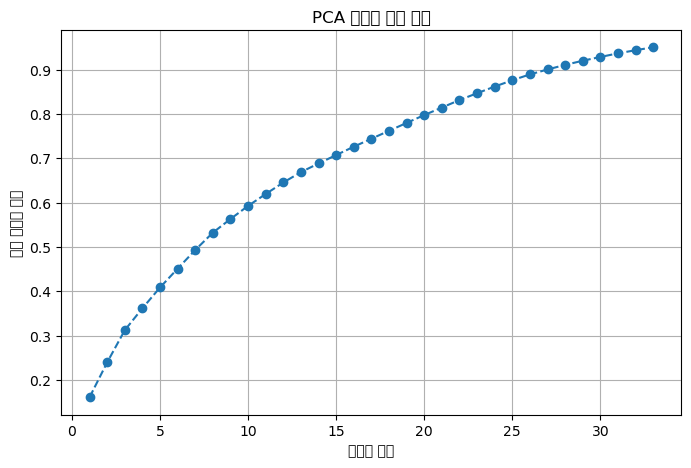

In [ ]:
# # 누적 분산 비율 계산
# cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# # 그래프 그리기
# plt.figure(figsize=(8,5))
# plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
# plt.xlabel('주성분 개수')
# plt.ylabel('누적 설명된 분산')
# plt.title('PCA 설명된 분산 비율')
# plt.grid(True)
# plt.show()